In [1]:

# The basic stable diffusion pipelines (InstructPix2Pix)
import PIL
import requests
import torch
from io import BytesIO
from google.colab import drive
import os
from google.colab import userdata
userdata.get('HF_TOKEN')


from diffusers import StableDiffusionInstructPix2PixPipeline

pipe = StableDiffusionInstructPix2PixPipeline.from_pretrained( "timbrooks/instruct-pix2pix", torch_dtype=torch.float16)




Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--timbrooks--instruct-pix2pix/snapshots/31519b5cb02a7fd89b906d88731cd4d6a7bbf88d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--timbrooks--instruct-pix2pix/snapshots/31519b5cb02a7fd89b906d88731cd4d6a7bbf88d/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
from PIL import Image
pipe = pipe.to("cuda")

  0%|          | 0/100 [00:00<?, ?it/s]

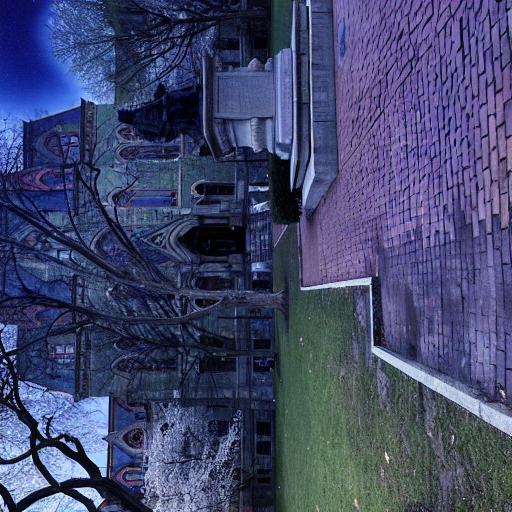

In [12]:
import torch
from PIL import Image, ImageOps

raw_image = Image.open("/content/collegehall_cloudy_day_front_facing2.jpg")


image = ImageOps.fit(raw_image, (512, 512), method=Image.Resampling.LANCZOS)

prompt = "make the time midnight with stars and moon on the sky"

generator = torch.manual_seed(42)

result_image = pipe(
    prompt=prompt,
    image=image,
    guidance_scale=7.5,        # Text guidance (higher = forces more rain/night)
    image_guidance_scale=1.5,  # Image guidance (higher = keeps original building shape stricter)
    generator=generator
).images[0]

# Display the result
result_image